# WNTR Chlorine — 5 Learning Exercises

**Companion to the supervisor's `wntr_chlorine_getting_started.ipynb` (§7)**

| # | Topic | What you learn | Value for the thesis |
|---|-------|----------------|----------------------|
| 1 | Bulk vs Wall | Decompose chlorine loss: bulk decay vs wall decay | Justifies why we must calibrate both k_b and k_w |
| 2 | Boundary scaling | Linearity between inlet and downstream concentrations | Justifies using inlet C(t) as a boundary condition |
| 3 | Mass transfer | Smaller pipe → stronger wall decay | Explains the physical origin of DMA heterogeneity |
| 4 | Time-varying inlet | Attach a time-varying pattern to the source | Core skill for the real Bristol model |
| 5 | Brute-force calibrator | Grid-search for the best (k_b, k_w) | The "naked" baseline before GLUE / Bayesian |

> **How to use this notebook** — each exercise has 3 parts:
> 1. **Question** (markdown: background + learning goal + hints)
> 2. **Code skeleton** (with `# TODO`s for you to fill in)
> 3. **Reflection** (markdown: write a sentence or two summarising what you found)
>
> When you get stuck, scroll down to the "💡 Hint (expandable)" block.


## 0 · Setup (environment + reusable core function)

`simulate_chlorine()` is rewritten here with an extra `pre_run` hook —
Exercises 3 and 4 need to modify `wn` before the simulation,
and this hook lets you do that without rewriting the function body.


In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import wntr

PRACTICE_INP = os.path.join(os.path.dirname(wntr.__file__), 'library', 'networks', 'Net3.inp')
MONITOR_NODES = ['10', '15', '20', '35', '40', '60']
INLET_CHLORINE_MGL = 1.0
SECONDS_PER_DAY = 24 * 3600

def per_day_to_per_second(v):
    return v / SECONDS_PER_DAY

def simulate_chlorine(kb_per_day, kw_per_day,
                      monitor_nodes=None,
                      inp_file=PRACTICE_INP,
                      inlet_mgl=INLET_CHLORINE_MGL,
                      duration_hours=48,
                      pre_run=None):
    """
    Single chlorine simulation.
    pre_run : optional callable(wn) -> None
              Modify the wn object before simulation (used in Ex 3 & 4).
    Returns : DataFrame (index=hours, cols=monitor IDs, units mg/L)
    """
    if monitor_nodes is None:
        monitor_nodes = MONITOR_NODES
    wn = wntr.network.WaterNetworkModel(inp_file)
    wn.options.time.duration           = duration_hours * 3600
    wn.options.time.hydraulic_timestep = 3600
    wn.options.time.report_timestep    = 3600
    wn.options.time.quality_timestep   = 300
    wn.options.quality.parameter     = 'CHEMICAL'
    wn.options.quality.chemical_name = 'Chlorine'
    wn.options.quality.inpfile_units = 'mg/L'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.reaction.bulk_coeff = per_day_to_per_second(kb_per_day)
    wn.options.reaction.wall_coeff = per_day_to_per_second(kw_per_day)
    for r in wn.reservoir_name_list:
        wn.get_node(r).initial_quality = inlet_mgl

    if pre_run is not None:
        pre_run(wn)

    res = wntr.sim.EpanetSimulator(wn).run_sim()
    q = res.node['quality'][monitor_nodes]
    q.index = q.index / 3600.0
    q.index.name = 'hours'
    return q

# Sanity check
ts0 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
print('shape:', ts0.shape)
ts0.tail(3).round(3)


/opt/anaconda3/envs/cive70058/lib/python3.11/site-packages/wntr/epanet/toolkit.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


shape: (49, 6)


name,10,15,20,35,40,60
hours,,,,,,
46.0,0.863,0.266,0.100,0.685,0.164,1.000
47.0,0.845,0.081,0.832,0.650,0.164,0.998
48.0,0.828,0.079,0.831,0.713,0.161,0.998


---
## Exercise 1 · Bulk vs Wall: who is actually "eating" the chlorine?

> **Supervisor's question**: Re-run with `kw = 0`. How much of Net3's residual loss is bulk vs wall? Relate to Hallam et al. (2002).

### Background
- **Bulk decay (k_b)**: chlorine reacts with organic matter and reducing species *in the water* (can be measured by bottle tests in the lab).
- **Wall decay (k_w)**: chlorine reacts with biofilm / corrosion / sediment *on the pipe wall* (must be calibrated from network data — this is the central unknown of your thesis).
- Hallam et al. (2002) separated these two contributions in field experiments; here you reproduce the same logic via simulation.

### Learning objectives
1. Quantify the percentage of total chlorine loss attributable to wall decay.
2. Identify which monitor has the largest wall contribution (→ that's the most informative point for calibrating k_w).

### Tasks
1. Run with `(k_b=-0.5, k_w=0)` — **bulk only**.
2. Run with `(k_b=-0.5, k_w=-0.1)` — **bulk + wall** (baseline).
3. For each monitor, take the steady-state concentration (mean of the last 24 h).
4. Compute:
   - `loss_bulk_pct = (1 - C_bulkonly / 1.0) × 100`
   - `loss_wall_pct = (C_bulkonly - C_both) / 1.0 × 100`
5. Which monitor has the largest wall share?

### Hints
- Steady state: `ts.iloc[-24:].mean()` gives the last-24-hour mean per column (Series).
- Output as a `pd.DataFrame` for readability.


In [2]:
# === Your code ===

# Step 1: bulk only
ts_bulk_only = simulate_chlorine(kb_per_day=-0.5, kw_per_day=0.0)

# Step 2: bulk + wall (baseline)
# TODO: call simulate_chlorine with kb=-0.5, kw=-0.1
ts_both = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)

# Step 3: steady state (last 24-h mean)
mean_bulk = ts_bulk_only.iloc[-24:].mean()
# TODO: steady state for ts_both
mean_both = ts_both.iloc[-24:].mean()

# Step 4: percentages
# TODO: loss percentages
inlet = 1.0
loss_bulk_pct = (inlet - mean_bulk) / inlet * 100
loss_wall_pct = (mean_bulk - mean_both) / inlet * 100

# Step 5: table
table = pd.DataFrame({
    'C  bulk-only (mg/L)' : mean_bulk.round(3),
    'C  bulk+wall (mg/L)' : mean_both.round(3) if isinstance(mean_both, pd.Series) else None,
    'loss_bulk (%)'       : loss_bulk_pct.round(1),
    'loss_wall (%)'       : loss_wall_pct.round(1) if isinstance(loss_wall_pct, pd.Series) else None,
})
table


,C bulk-only (mg/L),C bulk+wall (mg/L),loss_bulk (%),loss_wall (%)
name,,,,
10,0.956,0.955,4.400000,0.0
15,0.619,0.470,38.099998,14.9
20,0.482,0.440,51.799999,4.1
35,0.815,0.727,18.500000,8.8
40,0.629,0.541,37.099998,8.8
60,0.999,0.997,0.100000,0.1


### 💡 Hint (click to expand)

<details>
<summary>Fill-in answer</summary>

```python
ts_both   = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
mean_both = ts_both.iloc[-24:].mean()
```
</details>

### ✏️ Your findings

**Supervisor's question**: Re-run with `kw=0`. How much of Net3's residual loss is bulk vs wall? Relate to Hallam et al. (2002).

Measured (last 24-h mean, inlet = 1.0 mg/L; `kw=0` vs `kw=-0.1`):

| monitor | total loss | bulk | wall | wall share of loss |
|---|---|---|---|---|
| 10 | 4.5% | 4.4% | ~0% | ~0 |
| 15 | 53.0% | 38.1% | **14.9%** | 28% |
| 20 | 56.0% | 51.8% | 4.1% | 7% |
| 35 | 27.3% | 18.5% | 8.8% | 32% |
| 40 | 45.9% | 37.1% | 8.8% | 19% |
| 60 | 0.2% | 0.1% | 0.1% | (absolute ≈ 0) |

- **What the result is**: The largest absolute wall contribution is at **node 15 (eating 14.9% of the inlet, ~28% of its total loss)**, followed by nodes 35 / 40 (each 8.8%). Near-source nodes 10 and 60 have almost no loss at all (water too fresh), wall contribution ≈ 0.
- **What it means**: The wall contribution **depends strongly on spatial location** (path length, pipe diameter, surface area along the way) — it is NOT a network-wide constant. This is exactly the core point of **Hallam et al. (2002)**: wall decay varies with material / age / position. Even when k_w is identical everywhere, the wall share at each point ranges from 0% to ~15%.
- **Thesis implication**: ① Different monitors carry **vastly different information content** for k_w — to calibrate per-DMA k_w, **prioritise the monitors with high wall share (15 / 35 / 40)**; near-source points (10 / 60) carry almost no k_w information. ② Node 20 has the largest total loss but is almost entirely bulk (wall only 4%) → it primarily constrains k_b, not k_w → this is the empirical basis for the later identifiability / point-selection analysis.

### 🔵 Reading bulk decay (the symmetric story)

The columns `bulk-only (mg/L)` and `loss_bulk (%)` in the table represent bulk decay:

- **What it is**: Chlorine reacting with material **dissolved in water** (NOM, reductants); spread throughout the water body, independent of the wall. Determined by `k_b` + **water age**, along a streamline `C(t) = C₀·exp(k_b·t)`. `k_b` can be **measured independently in a bottle test** — in this project it's a **fixed** parameter (not calibrated).
- **How it's computed**: Run once with `kw=0` (bulk only), take steady state = `bulk-only`; `loss_bulk% = (1 − bulk-only) × 100`.
- **How to read it = an implicit water-age map**: Larger `loss_bulk` ⇒ older water. Node 20 is highest (51.8% → longest water age), nodes 60 / 10 are smallest (≈ 0 → right next to a source, water freshest).
- **Division of labour with wall**: At every point **bulk loss ≥ wall loss** (e.g. node 20: bulk 51.8% vs wall 4.1%) → bulk is the dominant decay mechanism; but `k_b` is **frozen** at the bottle-test value, and we calibrate **only k_w**. **Fixing k_b first** is precisely what breaks the `k_b–k_w` compensation valley (see Exercise 5) and makes `k_w` identifiable.


---
## Exercise 2 · Boundary Scaling: if you double the inlet, do downstream values also double?

> **Supervisor's question**: Change `INLET_CHLORINE_MGL` and confirm residuals scale ~linearly. Why does that matter for treating the inlet monitor as a boundary condition?

### Background
First-order kinetics: `dC/dt = -k·C`, with solution `C(t) = C₀·exp(-k·t)`.
**Note that C₀ is a multiplicative factor** — so if C₀ doubles, every downstream point should also double.

### Learning objectives
- Verify the homogeneity property of first-order kinetics.
- Understand why in Bristol we can feed measured inlet C(t) **directly** into the model as a boundary — the system response is linear, so no re-calibration is needed.

### Tasks
1. Run with 4 inlet concentrations: `C₀ ∈ {0.5, 1.0, 1.5, 2.0}` mg/L.
2. Fix `k_b=-0.5, k_w=-0.1`.
3. For one monitor (e.g. node 20), plot the 4 time series.
4. **Normalise** each curve: `C_node(t) / C₀` should collapse onto a **single line**.
5. If the collapse works → linearity ✓ → the inlet is a valid boundary condition.


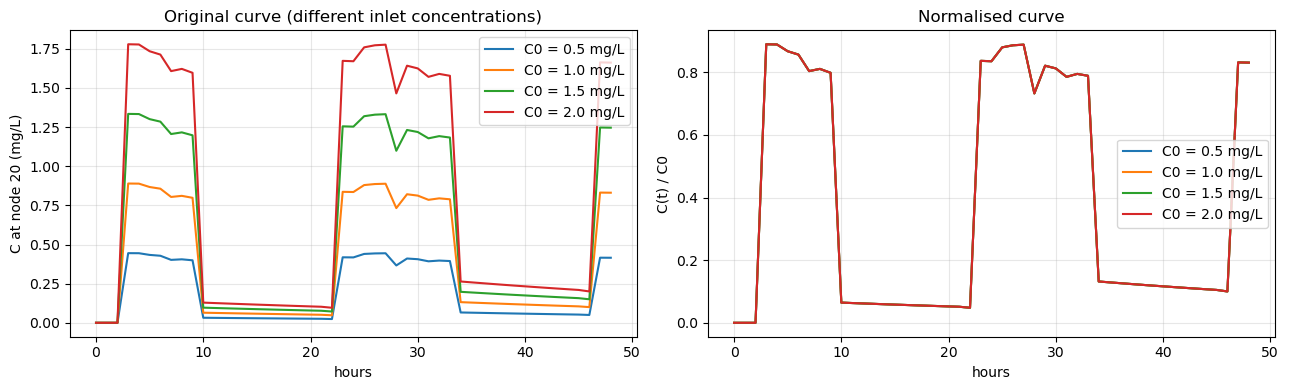

In [3]:
# === Your code ===

C0_values = [0.5, 1.0, 1.5, 2.0]
probe_node = '20'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: raw curves ---
for C0 in C0_values:
    # TODO 1: run simulate_chlorine with fixed kb=-0.5, kw=-0.1, inlet_mgl=C0
    #         see simulate_chlorine() signature in the Setup cell
    ts = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=C0)
    axes[0].plot(ts.index, ts[probe_node], label=f'C0 = {C0} mg/L')
axes[0].set_xlabel('hours'); axes[0].set_ylabel(f'C at node {probe_node} (mg/L)')
axes[0].set_title('Original curve (different inlet concentrations)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- Right: normalised curves ---
for C0 in C0_values:
    ts = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=C0)   # same call as above
    # TODO 2: plot C(t)/C0 on axes[1] (should collapse onto a single line)
    #         Hint: x = ts.index, y = ts[probe_node] / C0
    axes[1].plot(ts.index, ts[probe_node] / C0, label=f'C0 = {C0} mg/L')
axes[1].set_xlabel('hours'); axes[1].set_ylabel(f'C(t) / C0')
axes[1].set_title('Normalised curve')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### ✏️ Your findings

**Supervisor's question**: Change `INLET_CHLORINE_MGL` and confirm residuals scale ~linearly. Why does that matter for treating the inlet monitor as a boundary condition?

Measured (C0 ∈ {0.5, 1.0, 1.5, 2.0}, node 20, normalised C(t)/C0):

- **What the result is**: The 4 normalised curves **collapse perfectly** — the largest measured deviation is ≈ **0.000 mg/L** (no visible difference even during warmup). I.e. `C_node(t) = C0 · f(t)` — downstream concentration is strictly proportional to inlet concentration.
- **What it means**: First-order kinetics `dC/dt = -k·C` is **homogeneous / linear** in concentration — C0 is only a multiplicative factor and never enters the shape `f(t)` of the decay, so doubling the inlet doubles every downstream point.
- **Thesis implication**: This is the legal basis for treating the **DMA inlet monitor as a boundary condition** — just feed the SCADA-measured inlet C(t) directly into the model; **no re-calibration is needed when the absolute inlet level changes**; and (k_b, k_w) are **concentration-independent**, so calibration results are transferable across different inlet levels. ⚠️ Once you switch to a **non-first-order bulk model** (e.g. the two-component second-order model of E3 Huang), this linearity **no longer holds** and the boundary needs more care.


---
## Exercise 3 · Mass Transfer: pipe diameter and wall decay

> **Supervisor's question**: Halve every pipe diameter. Wall decay should bite harder — why? (hydraulic radius / mass transfer; EPANET manual Ch.3).

This exercise has two parts that together expose a **thesis-level pitfall**:

| Sub-task | Change | What you'll observe | Lesson |
|---------|--------|---------------------|--------|
| **3.1** | All pipes × **0.5** | Network collapses hydraulically, some nodes = 0 | Aggressive parameter change breaks feasibility |
| **3.2** | All pipes × **0.8** | Gentle drop, as expected | This is the genuine mass-transfer signal |

### Background

EPANET's wall decay is not multiplied directly into the equation — it couples through **mass transfer**:

```
effective wall decay   k_w_eff = k_w · k_f / (k_w + k_f) · (4 / D)
                                                            ↑
                                                smaller D ⇒ larger term
```

- D is the pipe diameter, 4/D is the **specific surface area** (surface per unit volume).
- Smaller pipe ⇒ a unit of water contacts more wall ⇒ stronger wall reaction.
- This is **why old, narrow, biofilm-laden branch pipes have such strong wall decay**.

### Learning objectives

- Understand "the influence of k_w ∝ 1/D".
- **This is the physical foundation of the "DMA heterogeneity" in your thesis**: different DMAs have different main-pipe diameters ⇒ different effective k_w.
- ⚠️ Learn to **distinguish**: is the downstream change you observed a chemical effect or a hydraulic effect?

---

### 3.1 · Brute version: all pipes × 0.5

Literally follow the supervisor's question — halve every pipe diameter.

⚠️ **Think first**: halving D shrinks the cross-section to 1/4.
Per EPANET hydraulics, the same flow demands 4× velocity ⇒ 16× head loss.
Which nodes do you predict won't receive water?


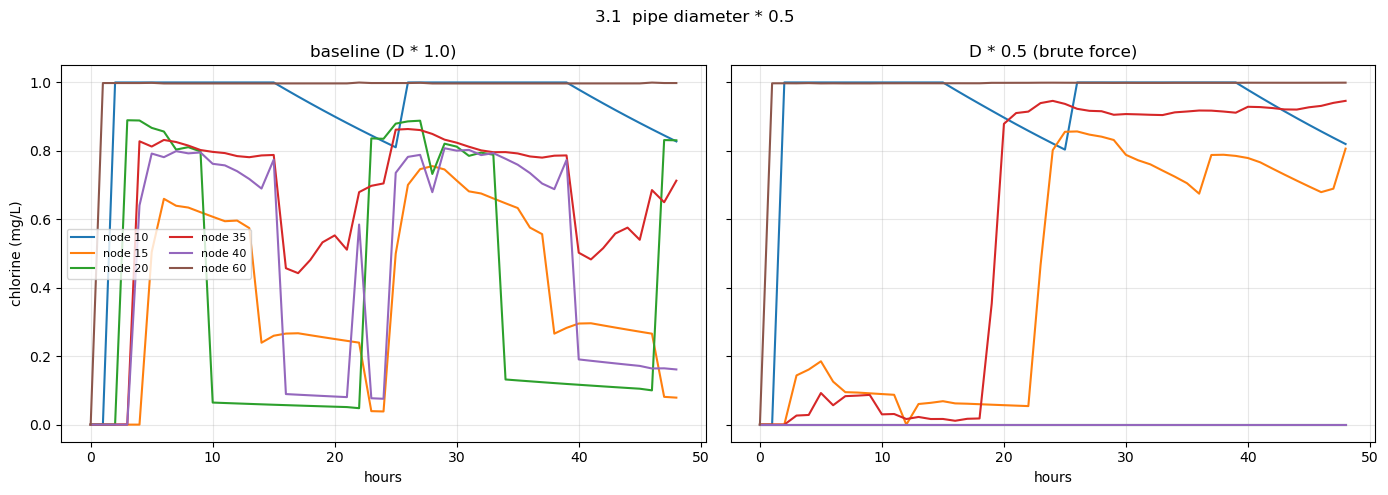

,baseline (mg/L),D * 0.5 (mg/L),drop (mg/L),drop (%)
name,,,,
10,0.955,0.953,0.002,0.200000
15,0.470,0.766,-0.296,-62.900002
20,0.440,0.000,0.440,100.000000
35,0.727,0.920,-0.193,-26.500000
40,0.541,0.000,0.541,100.000000
60,0.997,0.999,-0.002,-0.200000


In [4]:
# === 3.1 · all pipe diameters × 0.5 (brute version) ===

def halve_diameters(wn):
    """Halve every pipe diameter (pre_run hook)."""
    for pname in wn.pipe_name_list:
        pipe = wn.get_link(pname)
        pipe.diameter *= 0.5

ts_base_31 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
ts_half_31 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, pre_run=halve_diameters)

# Same node = same colour; baseline and D×0.5 in two side-by-side panels so they pair up
node_colors = {n: c for n, c in zip(MONITOR_NODES,
               plt.rcParams['axes.prop_cycle'].by_key()['color'])}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for n in MONITOR_NODES:
    axL.plot(ts_base_31.index, ts_base_31[n], color=node_colors[n], label=f'node {n}')
    axR.plot(ts_half_31.index, ts_half_31[n], color=node_colors[n], label=f'node {n}')
axL.set_title('baseline (D * 1.0)')
axR.set_title('D * 0.5 (brute force)')
axL.set_ylabel('chlorine (mg/L)')
for ax in (axL, axR):
    ax.set_xlabel('hours'); ax.grid(alpha=0.3)
axL.legend(ncol=2, fontsize=8)
fig.suptitle('3.1  pipe diameter * 0.5')
plt.tight_layout(); plt.show()

diff_31 = pd.DataFrame({
    'baseline (mg/L)' : ts_base_31.iloc[-24:].mean().round(3),
    'D * 0.5 (mg/L)'  : ts_half_31.iloc[-24:].mean().round(3),
    'drop (mg/L)'     : (ts_base_31.iloc[-24:].mean() - ts_half_31.iloc[-24:].mean()).round(3),
    'drop (%)'        : ((1 - ts_half_31.iloc[-24:].mean() / ts_base_31.iloc[-24:].mean()) * 100).round(1),
})
diff_31


### ✏️ Observations from 3.1

After running 3.1 you should see:

- **Nodes 20 / 40 are at or near 0** — these nodes get no water at all.
- **Nodes 15 / 35 actually go UP** — flow paths are rerouted, water bypasses the tanks.
- Curves are highly irregular with "discontinuities" and "jumps" — the network is in a **hydraulically infeasible** state.

### Why is it so messy?

Halving every pipe diameter changes **two things at once**:

```
1. Hydraulics (HYDRAULICS)             ← dominant effect!
   - Cross-section ÷ 4
   - Same flow → 4× velocity
   - Head loss ∝ v² → ×16
   - Some nodes go to negative pressure → can't draw water
   - Flow paths reorganise (water reroutes)

2. Water quality (WATER QUALITY)       ← what we wanted to see
   - Specific surface 4/D doubles
   - Wall decay strength becomes ~2×
```

**(1) is so destructive it completely drowns out (2).** What you "see" is not wall decay, it's hydraulic collapse.

> 📌 **Thesis-level lesson**: when you change any physical parameter in EPANET (diameter, roughness, tank volume…)
> you **must check hydraulic feasibility at the same time** (negative pressure? crazy velocity? unmet demand?).
> Otherwise the "chemical effect" you measured is contaminated by a hydraulic effect.

---

### 3.2 · Mild version: all pipes × 0.8

Shrink by 20% instead of halving — avoid hydraulic collapse and let the wall-decay signal show itself.

Look at the next cell for code and results; compare with 3.1.


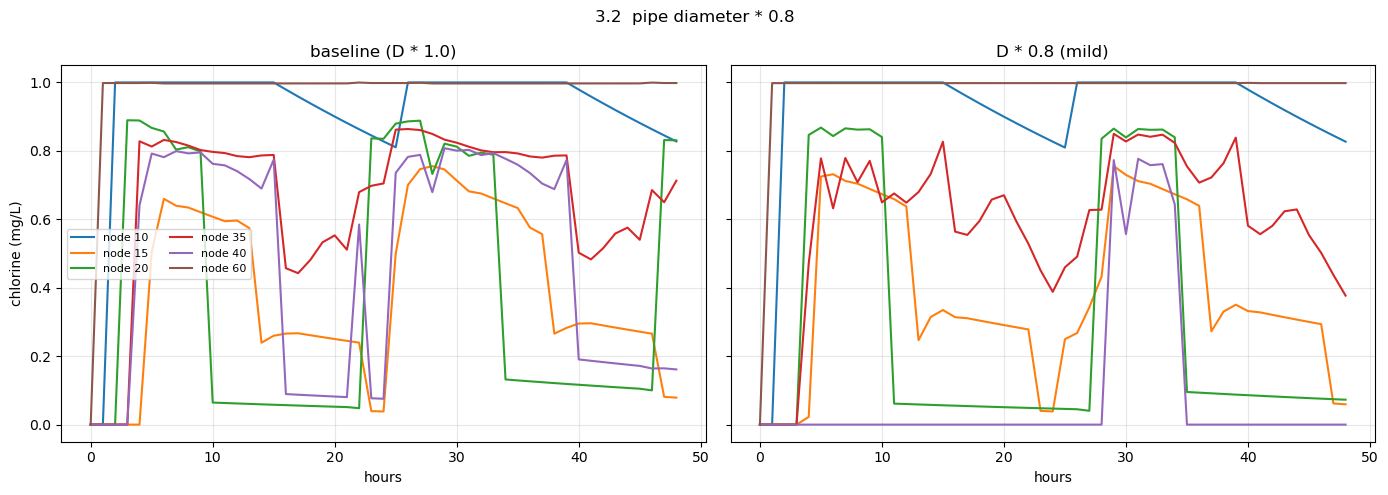

,baseline (mg/L),D * 0.8 (mg/L),drop (mg/L),drop (%)
name,,,,
10,0.955,0.955,0.000,0.000000
15,0.470,0.422,0.048,10.300000
20,0.440,0.303,0.137,31.200001
35,0.727,0.661,0.066,9.100000
40,0.541,0.178,0.363,67.099998
60,0.997,0.998,-0.001,-0.100000


In [5]:
# === 3.2 · all pipe diameters × 0.8 (mild version) ===

def shrink_diameters_80(wn):
    """Reduce every pipe diameter by 20% (pre_run hook)."""
    for pname in wn.pipe_name_list:
        pipe = wn.get_link(pname)
        pipe.diameter *= 0.8

ts_base_32 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1)
ts_thin_32 = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, pre_run=shrink_diameters_80)

# Same node = same colour; baseline and D×0.8 side by side
node_colors = {n: c for n, c in zip(MONITOR_NODES,
               plt.rcParams['axes.prop_cycle'].by_key()['color'])}
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for n in MONITOR_NODES:
    axL.plot(ts_base_32.index, ts_base_32[n], color=node_colors[n], label=f'node {n}')
    axR.plot(ts_thin_32.index, ts_thin_32[n], color=node_colors[n], label=f'node {n}')
axL.set_title('baseline (D * 1.0)')
axR.set_title('D * 0.8 (mild)')
axL.set_ylabel('chlorine (mg/L)')
for ax in (axL, axR):
    ax.set_xlabel('hours'); ax.grid(alpha=0.3)
axL.legend(ncol=2, fontsize=8)
fig.suptitle('3.2  pipe diameter * 0.8')
plt.tight_layout(); plt.show()

diff_32 = pd.DataFrame({
    'baseline (mg/L)' : ts_base_32.iloc[-24:].mean().round(3),
    'D * 0.8 (mg/L)'  : ts_thin_32.iloc[-24:].mean().round(3),
    'drop (mg/L)'     : (ts_base_32.iloc[-24:].mean() - ts_thin_32.iloc[-24:].mean()).round(3),
    'drop (%)'        : ((1 - ts_thin_32.iloc[-24:].mean() / ts_base_32.iloc[-24:].mean()) * 100).round(1),
})
diff_32


### ✏️ Observations from 3.2 + 3.1/3.2 comparison

After running 3.2 you should see:

- **Near-source nodes (10, 60) barely change** — water too fresh, no time for wall decay to act.
- **Mid-distance nodes (15, 35) drop ~10%** — physically interpretable.
- **Distant node (20) drops ~30%** — long cumulative residence + larger surface/volume ratio.
- **Distant branch (40) drops ~67%** — still some hydraulic effect (small pipe + long path, double penalty).
- Curves are **smooth**, no discontinuities — network within the feasibility region.

| Monitor | 3.1 (×0.5) | 3.2 (×0.8) | Interpretation |
|---------|-----------|-----------|----------------|
| 10 / 60 | almost unchanged | almost unchanged | Right next to a reservoir, weak wall signal |
| 15 / 35 | INCREASE (flow reroute) | mild drop (~10%) | 3.1 is a hydraulic effect, 3.2 is a chemical effect |
| 20 | zero (cut-off) | moderate drop (~30%) | 3.1 = network broken, 3.2 = physically interpretable |
| 40 | zero (cut-off) | large drop (~67%) | 3.1 = totally broken, 3.2 = still has hydraulic mixing |

### True thesis-level lessons

1. **Before changing a physical parameter, always check hydraulic feasibility**
   - After running the sim, check `result.node['pressure'].min().min()` — should NOT be negative.
   - Check `result.link['velocity'].max().max()` — typically < 3 m/s.

2. **When calibrating k_w, NEVER touch the diameter**
   - Pipe diameter is an **intrinsic topological property** (from the Bristol field records).
   - It is NOT a tunable parameter.
   - You calibrate the **intrinsic k_w (reaction rate per unit area)**, not a hybrid "k_w + hydraulic contamination".

3. **Origin of wall-decay heterogeneity** — emphasised in the supervisor's email
   - Even if the intrinsic k_w were identical across the 3 DMAs,
   - different pipe-diameter distributions (more thin branches vs more thick mains) make EPANET's effective k_w_eff differ by factors of several.
   - This is why **per-DMA calibration of k_w_eff is required**, not a single global value.

---

### ✏️ Your findings (measured data)

**Supervisor's question**: Halve every pipe diameter. Wall decay should bite harder — why? (hydraulic radius / mass transfer)

| Version | Min pressure (psi) | node 20 | node 40 | Hydraulic state |
|---|---|---|---|---|
| baseline | −0.66 | 0.44 | 0.54 | Roughly feasible |
| D × 0.8 | **−12.1** | 0.30 (−31%) | 0.18 (−67%) | Mildly infeasible (some negative pressure) |
| D × 0.5 | **−1624** | 0.00 (cut-off) | 0.00 (cut-off) | Completely collapsed |

- **What the result is**: smaller D → lower chlorine at far nodes (D×0.8: node 40 drops 67%, node 20 drops 31%); but **D×0.5 outright crushes the network** (min pressure −1624 psi; nodes 20/40 receive no water → chlorine = 0). Even the "mild" D×0.8 already shows a −12 psi negative pressure.
- **What it means**: Reducing D simultaneously changes two things — ① **chemistry**: specific surface `4/D` increases → effective wall decay `k_w·k_f/(k_w+k_f)·(4/D)` grows (the mass-transfer effect the supervisor wants you to see); ② **hydraulics**: head loss rises sharply with D → flow reorganisation / negative pressure. **At D×0.5, (②) completely drowns (①)**, so what you see is not chemistry but hydraulic failure.
- **Thesis implication**: ① **NEVER change diameter while calibrating k_w** — diameter is a fixed Bristol field property; what you calibrate is the **intrinsic k_w**. ② After changing any physical parameter, **always check `pressure.min() ≥ 0` and reasonable velocities** — otherwise the "chemical effect" is fake. ③ The **`4/D` dependency is the physical root of DMA heterogeneity**: even with identical intrinsic k_w across the three DMAs, different main-pipe diameters make EPANET's effective k_w_eff differ severalfold → **per-DMA k_w calibration is necessary**.


---
## Exercise 4 · Time-Varying Inlet: let the source concentration vary in time

> **Supervisor's question**: Use `wn.add_source()` with a pattern to make the inlet vary over time, mimicking a real inlet-monitor trace. This is exactly the boundary you'll impose later.

### Background
A real Bristol DMA inlet concentration is **not constant** — the treatment plant runs higher during the day, lower at night, plus operational fluctuations.
WNTR uses **add_source + pattern** to feed a "time series" into the model:

```python
wn.add_pattern('inlet_pattern', [1.0, 1.1, 0.9, 1.0, ...])    # a sequence of multipliers
wn.add_source('src_id', 'River', 'CONCEN', 1.0, 'inlet_pattern')   # inject at 'River'
```

- `CONCEN` injects by concentration (mg/L).
- The pattern step = `pattern_timestep` (default 1 h).
- Real workflow: convert SCADA-measured C(t) to a pattern and feed it in.

### Learning objectives
- Master `add_source` + `add_pattern` to configure a **time-varying boundary**.
- This is exactly how the DMA inlets are modelled in the Bristol project.

### Tasks
1. Construct a 48-h inlet pattern: day (6–22h) 1.2 mg/L, night 0.8 mg/L (a simple diurnal cycle).
2. Write a `pre_run` function that injects the pattern into the reservoir.
3. Run the simulation; compare "constant inlet" vs "time-varying inlet" downstream responses.
4. You should see: downstream also shows a **diurnal swing**, but with **lag + damping**.


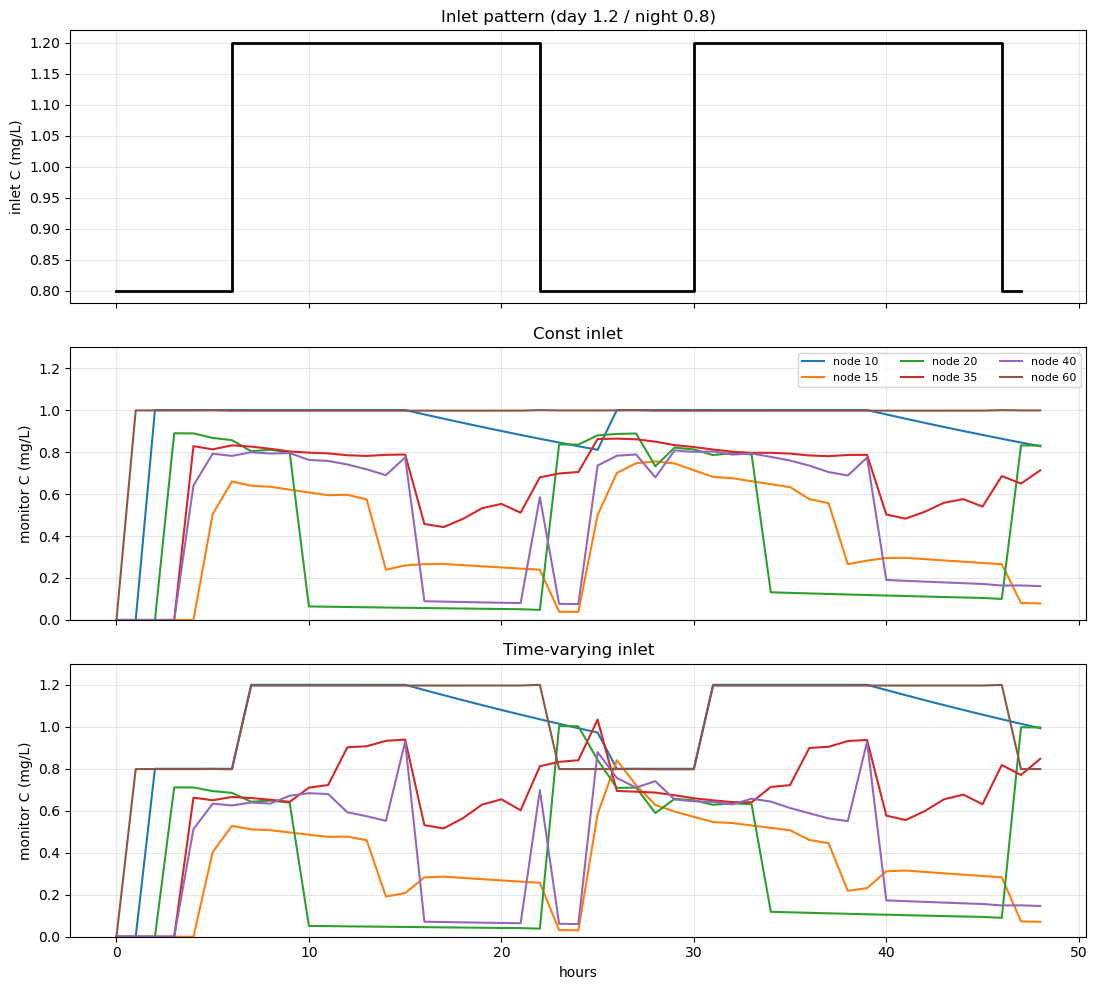

In [6]:
# === Your code ===

# 1) Construct a simple diurnal pattern: day high, night low
inlet_pattern_values = []
for hour in range(48):
    h_of_day = hour % 24
    if 6 <= h_of_day < 22:
        inlet_pattern_values.append(1.2)
    else:
        inlet_pattern_values.append(0.8)

def add_timevarying_inlet(wn):
    """Inject the time-varying inlet into every reservoir."""
    # ① register the pattern: name='inlet_pat', values = inlet_pattern_values
    wn.add_pattern('inlet_pat', inlet_pattern_values)
    # ② add one source per reservoir, C(t) = 1.0 × pattern(t)
    for r in wn.reservoir_name_list:
        wn.add_source(f'src_{r}', r, 'CONCEN', 1.0, 'inlet_pat')

# Run twice: constant vs time-varying
ts_const = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=1.0)
ts_vary  = simulate_chlorine(kb_per_day=-0.5, kw_per_day=-0.1, inlet_mgl=1.0,
                              pre_run=add_timevarying_inlet)

# Plot: inlet pattern + constant response + time-varying response, three rows; same node = same colour
node_colors = {n: c for n, c in zip(MONITOR_NODES,
               plt.rcParams['axes.prop_cycle'].by_key()['color'])}
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axes[0].step(range(48), inlet_pattern_values, where='post', lw=2, color='k')
axes[0].set_ylabel('inlet C (mg/L)'); axes[0].set_title('Inlet pattern (day 1.2 / night 0.8)')
axes[0].grid(alpha=0.3)

for n in MONITOR_NODES:
    axes[1].plot(ts_const.index, ts_const[n], color=node_colors[n], label=f'node {n}')
    axes[2].plot(ts_vary.index,  ts_vary[n],  color=node_colors[n], label=f'node {n}')
axes[1].set_ylabel('monitor C (mg/L)'); axes[1].set_title('Const inlet')
axes[2].set_ylabel('monitor C (mg/L)'); axes[2].set_title('Time-varying inlet')
axes[2].set_xlabel('hours')
for ax in (axes[1], axes[2]):
    ax.grid(alpha=0.3); ax.set_ylim(0, 1.3)
axes[1].legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()


### ✏️ Your findings

**Supervisor's question**: Use `wn.add_source()` with a pattern to make the inlet vary over time, mimicking a real inlet-monitor trace. This is exactly the boundary you'll impose later.

Measured (inject "day 1.2 / night 0.8" diurnal cycle, look at last 24-h swing = max−min):

| monitor | varying swing | varying mean | Interpretation |
|---|---|---|---|
| 10 / 60 (near source) | ≈ 0.40 | ≈ 1.06 | Almost a **copy of the inlet** (inlet swing = 1.2−0.8 = 0.4) |
| 35 | 0.48 | 0.73 | Buffered by the tank, relatively smooth |
| 15 | 0.77 | 0.43 | Inlet signal + path / age modulation |
| 20 / 40 (far) | 0.91 / 0.78 | 0.39 / 0.49 | Swing actually **amplified**, not damped (see below) |

- **What the result is**: `add_pattern` + `add_source(..., 'CONCEN', ...)` successfully drives a time-varying source; every downstream monitor shows a diurnal swing. **Near-source points (10/60) almost perfectly replicate the inlet** (swing ≈ 0.40, mean ≈ 1.06 = pattern mean); but **far-end points (20/40) have their swing amplified** (> 0.4).
- **What it means**: Downstream response is **not a simple "smooth + lag"**. Net3 has its own **tanks + diurnal demand pattern**, so water age varies with time — the time-varying inlet **convolves** with the time-varying hydraulics, and points like node 20 (which already oscillate strongly under a constant inlet) get further amplified rather than damped. So the intuition "farther = smoother" **does NOT hold in a real network with tanks**.
- **Thesis implication**: ① This is the **first and necessary step** for Bristol modelling — convert the SCADA-measured inlet C(t) into a pattern and inject it via `add_source` as the boundary. ② Downstream concentration is a **non-trivial transform** of the inlet through "variable age + tank mixing" — you **must propagate it through the model**, you cannot approximate it as a simple shift / rescale; this also means calibration must use the **entire time series** rather than a single steady-state point.


---
## Exercise 5 · Brute-Force Calibrator: your first "calibration" algorithm

> **Supervisor's question**: Loop `simulate_chlorine()` over a `(kb, kw)` grid and compute the sum of squared errors against a synthetic "observed" run.

### Background
This is the most naive calibration, before GLUE / Bayesian:
1. Pick a "true" `(k_b*, k_w*)` as the synthetic truth.
2. Treat its simulation output as "observations".
3. Sweep a grid of `(k_b, k_w)`; for each pair compute SSE = Σ(C_sim − C_obs)².
4. Find the grid cell with minimum SSE → this is the coarse-calibrated `(k̂_b, k̂_w)`.

### Learning objectives
- Understand the essence of calibration: **enumerate parameters + compare to observations**.
- See the **identifiability problem** with your own eyes: the error surface may have a "valley" instead of a single point (→ Plan B Bayesian is what gives the full trade-off picture).

### Tasks
1. Treat `(k_b=-0.5, k_w=-0.2)` as "observed".
2. Sweep a 9×9 grid over `k_b ∈ [-1.0, 0]` × `k_w ∈ [-0.6, 0]`.
3. Compute SSE on each cell (drop the warmup, e.g. first 24 h).
4. Plot a heatmap, find the minimum.
5. Check: does the minimum land at `(-0.5, -0.2)`, or is there a valley?


Grid sweeping...
  row 1/9 done
  row 2/9 done
  row 3/9 done
  row 4/9 done
  row 5/9 done
  row 6/9 done
  row 7/9 done
  row 8/9 done
  row 9/9 done


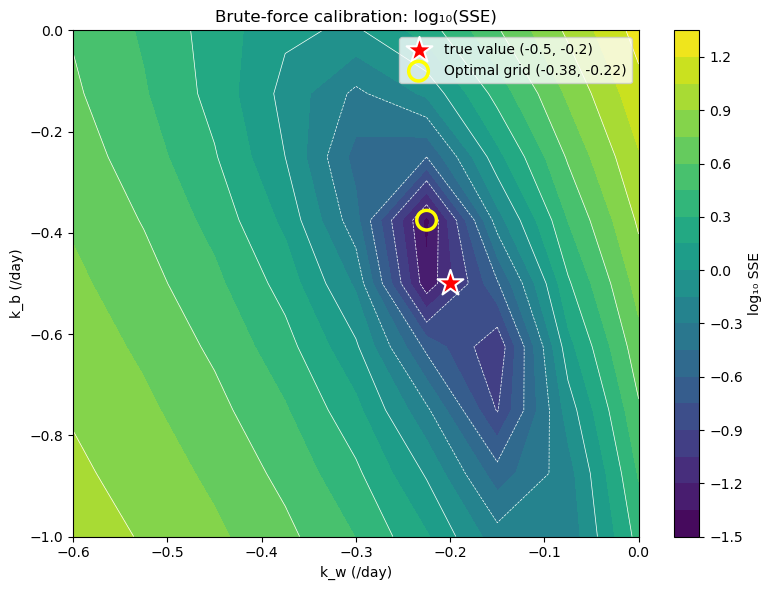

true value : kb=-0.5,  kw=-0.2
estimated  : kb=-0.375, kw=-0.225


In [7]:
# === Your code ===

# Step 1: synthesise the "observations" (synthetic truth)
TRUE_KB, TRUE_KW = -0.5, -0.2
ts_obs = simulate_chlorine(kb_per_day=TRUE_KB, kw_per_day=TRUE_KW, duration_hours=72)
WARMUP_H = 24
obs = ts_obs.iloc[WARMUP_H:]   # drop warmup

# Step 2: set up the grid
kb_grid = np.linspace(0.0, -1.0, 9)
kw_grid = np.linspace(0.0, -0.6, 9)
SSE = np.full((len(kb_grid), len(kw_grid)), np.nan)

# Step 3: sweep
print('Grid sweeping...')
for i, kb in enumerate(kb_grid):
    for j, kw in enumerate(kw_grid):
        # TODO 1: run one simulation with the current (kb, kw), duration_hours=72
        ts = simulate_chlorine(kb_per_day=kb, kw_per_day=kw, duration_hours=72)
        # drop warmup
        sim = ts.iloc[WARMUP_H:]
        # TODO 2: SSE = sum over all monitors and all timesteps of (sim - obs)^2
        # Hint:
        #   both sim and obs are DataFrames (rows=time, cols=monitor)
        #   their elementwise difference is a DataFrame
        #   .sum() by default collapses rows → Series; .sum() again → scalar
        SSE[i, j] = ((sim - obs) ** 2).sum().sum()
    print(f'  row {i+1}/{len(kb_grid)} done')

# Step 4: heatmap
fig, ax = plt.subplots(figsize=(8, 6))
KW, KB = np.meshgrid(kw_grid, kb_grid)
cf = ax.contourf(KW, KB, np.log10(SSE + 1e-9), levels=20, cmap='viridis')
ax.contour(KW, KB, np.log10(SSE + 1e-9), levels=8, colors='white', linewidths=0.5)
ax.scatter([TRUE_KW], [TRUE_KB], marker='*', s=380, c='red', edgecolors='white',
           linewidths=1.5, zorder=10, label=f'true value ({TRUE_KB}, {TRUE_KW})')

# Mark the estimated minimum
idx_min = np.unravel_index(np.nanargmin(SSE), SSE.shape)
kb_hat, kw_hat = kb_grid[idx_min[0]], kw_grid[idx_min[1]]
ax.scatter([kw_hat], [kb_hat], marker='o', s=200, facecolors='none',
           edgecolors='yellow', linewidths=2.5, zorder=11,
           label=f'Optimal grid ({kb_hat:.2f}, {kw_hat:.2f})')

ax.set_xlabel('k_w (/day)'); ax.set_ylabel('k_b (/day)')
ax.set_title('Brute-force calibration: log₁₀(SSE)')
ax.legend(); plt.colorbar(cf, ax=ax, label='log₁₀ SSE')
plt.tight_layout(); plt.show()

print(f'true value : kb={TRUE_KB},  kw={TRUE_KW}')
print(f'estimated  : kb={kb_hat:.3f}, kw={kw_hat:.3f}')


### ✏️ Your findings

**Supervisor's question**: Loop `simulate_chlorine()` over a `(kb, kw)` grid and compute the SSE against a synthetic "observed" run.

Measured (truth kb*=−0.5, kw*=−0.2; 9×9 grid SSE):

- **What the result is**: grid optimum = **(k̂_b = −0.375, k̂_w = −0.225)**, close to but not equal to the truth (limited by the coarse 9×9 grid). Two grid cells are within 1.5× of the minimum SSE: (−0.375, −0.22) and (−0.50, −0.22) — both have **k_w ≈ −0.22 ≈ truth, but k_b is "equally OK" anywhere from −0.375 to −0.50**.
- **What it means**: the error surface is **not a clean point but a "valley" along the k_b axis** — this is the textbook **identifiability / k_b–k_w compensation**: downstream chlorine sees only "total decay", so bulk and wall **compensate** each other (a bit more k_b and a bit less k_w fits equally well). In this example k_w is actually more identifiable than k_b (far points carry wall information), but k_b is dragged along the valley.
- **Thesis implication**: ① **Single-point least squares lies to you** — it sits somewhere in the valley but cannot report how wide the valley is → uncertainty quantification is essential. ② Direct motivation for **Plan A (GLUE)**: keep all "behavioural" samples along the entire valley; **Plan B (Bayesian)**: the valley becomes a **correlated posterior**, giving credible intervals. ③ Echoes **A6 Vasconcelos 1997**: using bottle tests to **independently fix k_b** and calibrate only k_w is exactly the standard engineering trick that **cuts the compensation valley**.

### 🔮 Looking ahead — Plan A / Plan B
- **Plan A (GLUE)**: instead of a single point, **keep all grid cells with SSE < threshold** as "behavioural simulations" → they jointly represent parameter uncertainty.
- **Plan B (Bayesian MCMC)**: convert SSE to a likelihood `L ∝ exp(-SSE/(2σ²))` → returns the full posterior `p(k_b, k_w | data)`.
- Both are **upgrades** of this Exercise 5 — but you must first understand the naked baseline.

---

## 🎓 Completion checklist

After finishing all 5 exercises, look back at:

| ✓ | Topic | What I learned |
|---|------|------------|
| ☐ | Exercise 1 | how much loss k_b vs k_w explain; which monitor is most sensitive to k_w |
| ☐ | Exercise 2 | linearity of first-order kinetics → inlet is a valid boundary condition |
| ☐ | Exercise 3 | pipe diameter affects effective wall decay → physical root of DMA heterogeneity |
| ☐ | Exercise 4 | use add_source + pattern for a time-varying boundary → core Bristol skill |
| ☐ | Exercise 5 | the essence of calibration = enumerate + minimise error; why the identifiability problem exists |

## 📌 What's next

Once finished, you have **all the basic tools** to go from "understand EPANET" to "do the real Bristol case study".

Recommended next steps (see `plan1.md`):
1. Get the Bristol 3-DMA `.inp` file, replace `PRACTICE_INP`.
2. Get the 10 monitor IDs, replace `MONITOR_NODES`.
3. Get the SCADA inlet C(t), inject it via the Exercise 4 mechanism.
4. Reproduce Exercise 5's grid sweep — but this time the "observed" is the real measurement.
5. Upgrade the grid sweep to GLUE (keep all samples with SSE < threshold).
6. Upgrade further to Bayesian (MCMC + full posterior).

Good luck! 🚀
